# 07 — Churn Campaign Priority and Capacity

A probability becomes valuable only when it guides an action. This notebook converts the logistic-regression champion into capacity scenarios and four understandable campaign-priority bands.

All cutoffs are learned from historical validation predictions. September remains an honest out-of-time test of how the policy behaves on a later population.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from customer_intelligence.churn import (
    assign_campaign_priority_bands, assign_risk_bands, build_logistic_pipeline, capacity_table,
    final_temporal_holdout, learn_risk_band_cutoffs,
    make_logistic_feature_contract, purged_rolling_splits,
    rolling_logistic_validation, tune_probability_threshold,
)

sns.set_theme(style='whitegrid')

## 1. Reproduce the champion using historical validation

We reproduce model and threshold selection so this notebook can run independently. The validation predictions are especially important: they represent what the model would have scored on genuinely later historical months.

In [2]:
churn_data = pd.read_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'churn_training_table.csv',
    parse_dates=['SnapshotDate'],
)
contract = make_logistic_feature_contract(churn_data)
folds = purged_rolling_splits(
    churn_data,
    pd.to_datetime(['2011-02-01', '2011-03-01', '2011-04-01', '2011-05-01']),
    horizon_days=90,
)
selected_c, validation_summary, validation_predictions = rolling_logistic_validation(
    churn_data, folds, [0.001, 0.01, 0.1, 1.0, 10.0], contract
)
selected_threshold, threshold_summary = tune_probability_threshold(
    validation_predictions, selected_c,
    [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75],
)
print(f'Champion C: {selected_c:g}')
print(f'High-risk decision threshold: {selected_threshold:.2f}')

Champion C: 0.01
High-risk decision threshold: 0.40


## 2. What happens at different campaign capacities?

Capacity means the percentage of customers the retention team can contact. Customers are ranked from highest to lowest probability. For example, 20% capacity means contacting only the top-risk fifth of the eligible population.

- **Precision**: expected share of contacted customers who churn.
- **Recall**: share of all churners reached by the campaign.
- **Lift**: targeted churn rate divided by the population churn rate.

In [3]:
selected_validation = validation_predictions.loc[
    validation_predictions['C'].eq(selected_c)
]
validation_capacity = capacity_table(
    selected_validation['Actual'], selected_validation['Probability'],
    fractions=[0.05, 0.10, 0.20, 0.30, 0.50],
)
display(validation_capacity.style.format({
    'Capacity': '{:.0%}', 'Precision': '{:.1%}',
    'Recall': '{:.1%}', 'Lift': '{:.2f}×',
}))

,Capacity,CustomersContacted,ChurnersReached,Precision,Recall,Lift
0,5%,651,567,87.1%,7.7%,1.54×
1,10%,1301,1117,85.9%,15.2%,1.51×
2,20%,2601,2147,82.5%,29.1%,1.46×
3,30%,3901,3167,81.2%,43.0%,1.43×
4,50%,6501,4957,76.2%,67.3%,1.35×


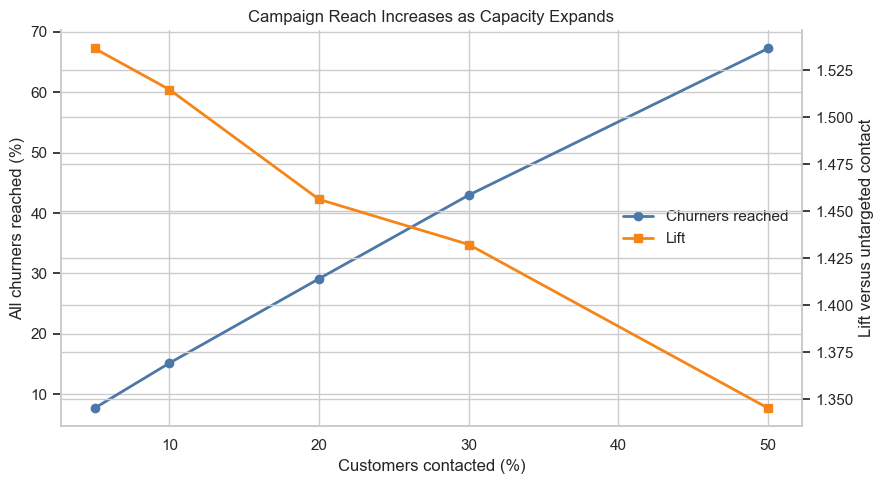

In [4]:
fig, ax1 = plt.subplots(figsize=(9, 5))
capacity_pct = validation_capacity['Capacity'] * 100
ax1.plot(capacity_pct, validation_capacity['Recall'] * 100,
         marker='o', linewidth=2, color='#4C78A8', label='Churners reached')
ax1.set(xlabel='Customers contacted (%)', ylabel='All churners reached (%)',
        title='Campaign Reach Increases as Capacity Expands')
ax2 = ax1.twinx()
ax2.plot(capacity_pct, validation_capacity['Lift'], marker='s', linewidth=2,
         color='#F58518', label='Lift')
ax2.set_ylabel('Lift versus untargeted contact')
lines = ax1.lines + ax2.lines
ax1.legend(lines, [line.get_label() for line in lines], frameon=False, loc='center right')
sns.despine(right=False)
plt.tight_layout()
plt.show()

## 3. Learn risk-band cutoffs without using September

The latest validation month's score distribution defines four initial bands. Using one month avoids mixing probabilities produced by four differently fitted fold models:

- **Very High diagnostic score:** validation's top 10%
- **High diagnostic score:** next 10%
- **Medium diagnostic score:** next 30%
- **Low diagnostic score:** bottom 50%

These fixed cutoffs are applied as a **monitoring diagnostic**: a changing share in each band warns that the score distribution has drifted. Because that drift can break campaign capacity, the operational action bands are assigned by rank: top 10% Very High, next 10% High, next 30% Medium, and bottom 50% Low.

In [5]:
# Use one coherent score distribution from the latest validation month.
# Pooling months would mix probabilities produced by differently fitted models.
latest_validation_date = selected_validation['ValidationDate'].max()
cutoff_validation = selected_validation.loc[
    selected_validation['ValidationDate'].eq(latest_validation_date)
]
risk_cutoffs = learn_risk_band_cutoffs(cutoff_validation['Probability'])
print(f'Cutoffs learned from: {latest_validation_date:%Y-%m-%d}')
pd.Series(risk_cutoffs, name='Minimum churn probability').to_frame().style.format('{:.1%}')

Cutoffs learned from: 2011-05-01


,Minimum churn probability
Medium,45.7%
High,70.2%
Very High,73.7%


## 4. Apply the frozen policy to the untouched September snapshot

The champion is trained on safely labelled development rows. July and August are purged because their outcomes overlap the September scoring date. September probabilities then receive the validation-derived bands.

In [6]:
development_idx, test_idx, purged_idx = final_temporal_holdout(
    churn_data, pd.Timestamp('2011-09-01'), horizon_days=90
)
model = build_logistic_pipeline(contract, regularization_c=selected_c)
model.fit(
    churn_data.loc[development_idx, contract.all_features],
    churn_data.loc[development_idx, 'Churn'],
)
scored_test = churn_data.loc[test_idx, ['Customer ID', 'SnapshotDate', 'Churn']].copy()
scored_test['ChurnProbability'] = model.predict_proba(
    churn_data.loc[test_idx, contract.all_features]
)[:, 1]
# Fixed bands are retained as a monitoring signal. A large change in their
# population share indicates that model scores have shifted over time.
scored_test['FixedScoreDiagnosticBand'] = assign_risk_bands(
    scored_test['ChurnProbability'], risk_cutoffs
)
# Operational bands follow campaign capacity: top 20% receives priority.
scored_test = scored_test.sort_values('Customer ID').reset_index(drop=True)
scored_test['CampaignPriorityBand'] = assign_campaign_priority_bands(
    scored_test['ChurnProbability']
)
scored_test.head()

,Customer ID,SnapshotDate,Churn,ChurnProbability,FixedScoreDiagnosticBand,CampaignPriorityBand
0,12347,2011-09-01,0,0.151473,Low,Standard monitoring
1,12348,2011-09-01,0,0.452459,Low,Priority 3 - Nurture
2,12352,2011-09-01,0,0.380492,Low,Priority 3 - Nurture
3,12353,2011-09-01,1,0.597548,Medium,Priority 2 - Targeted
4,12354,2011-09-01,1,0.603010,Medium,Priority 2 - Targeted


In [7]:
overall_test_churn = scored_test['Churn'].mean()
band_profile = (
    scored_test.groupby('CampaignPriorityBand', observed=True)
    .agg(Customers=('Customer ID', 'count'),
         AverageProbability=('ChurnProbability', 'mean'),
         ObservedChurnRate=('Churn', 'mean'))
    .reset_index()
)
band_profile['CustomerShare'] = band_profile['Customers'] / len(scored_test)
band_profile['ObservedLift'] = band_profile['ObservedChurnRate'] / overall_test_churn
display(band_profile.style.format({
    'AverageProbability': '{:.1%}', 'ObservedChurnRate': '{:.1%}',
    'CustomerShare': '{:.1%}', 'ObservedLift': '{:.2f}×',
}))

,CampaignPriorityBand,Customers,AverageProbability,ObservedChurnRate,CustomerShare,ObservedLift
0,Standard monitoring,1383,14.0%,21.5%,50.0%,0.55×
1,Priority 3 - Nurture,830,42.9%,48.0%,30.0%,1.22×
2,Priority 2 - Targeted,277,59.1%,64.6%,10.0%,1.64×
3,Priority 1 - Immediate,276,67.9%,77.2%,10.0%,1.96×


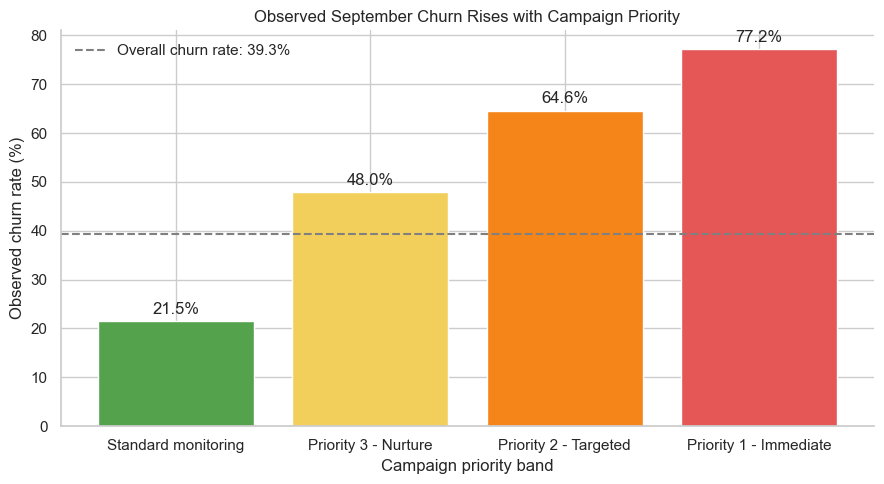

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#54A24B', '#F2CF5B', '#F58518', '#E45756']
bars = ax.bar(band_profile['CampaignPriorityBand'].astype(str),
              band_profile['ObservedChurnRate'] * 100, color=colors)
ax.axhline(overall_test_churn * 100, color='gray', linestyle='--',
           label=f'Overall churn rate: {overall_test_churn:.1%}')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set(title='Observed September Churn Rises with Campaign Priority',
       xlabel='Campaign priority band', ylabel='Observed churn rate (%)')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Attach an initial action policy

Actions should become more expensive and personalized as risk rises. These are operational recommendations, not causal claims that a discount will prevent churn. A future controlled experiment must measure incremental impact.

In [9]:
action_policy = {
    'Priority 1 - Immediate': 'Personalized outreach for the highest-ranked 10%; use segment and value',
    'Priority 2 - Targeted': 'Targeted retention message for the next-ranked 10%',
    'Priority 3 - Nurture': 'Automated email nurture or product reminder',
    'Standard monitoring': 'Normal low-cost engagement; no paid retention incentive',
}
scored_test['RecommendedAction'] = scored_test['CampaignPriorityBand'].astype(str).map(action_policy)
pd.DataFrame({
    'Campaign priority band': list(action_policy),
    'Recommended action': list(action_policy.values()),
})

,Campaign priority band,Recommended action
0,Priority 1 - Immediate,Personalized outreach for the highest-ranked 1...
1,Priority 2 - Targeted,Targeted retention message for the next-ranked...
2,Priority 3 - Nurture,Automated email nurture or product reminder
3,Standard monitoring,Normal low-cost engagement; no paid retention ...


## Stakeholder conclusion

The model now supports two related business decisions. The **capacity table** shows the trade-off between campaign size, churner coverage, and lift. The **campaign-priority bands** provide a stable policy for prioritizing treatment intensity.

The operational bands are intentionally capacity-oriented: they prioritize the top-ranked 20% even when absolute score distributions drift. Fixed validation cutoffs remain available for drift monitoring, while the separate 0.40 threshold describes the model's high-risk classification decision. These bands should not yet be called profit-optimal because contact cost, offer cost, customer margin, natural return probability, and treatment effectiveness are unknown. The next step is to combine churn risk with customer value and segmentation, then define an expected-value policy before producing the final scored-customer export.